In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "qnli"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['question', 'sentence', 'label', 'idx'],
    num_rows: 104743
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'question': 'When did the third Digimon series begin?',
 'sentence': 'Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deaths and more complex character development in the original Japanese.',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['question'], raw_train_dataset[5]['sentence']

("When is the term 'German dialects' used in regard to the German language?",
 'When talking about the German language, the term German dialects is only used for the traditional regional varieties.')

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'question': Value('string'),
 'sentence': Value('string'),
 'label': ClassLabel(names=['entailment', 'not_entailment']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["question"], example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["question", "sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 84]),
 'token_type_ids': torch.Size([32, 84]),
 'attention_mask': torch.Size([32, 84])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7970, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6875, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [28]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9134175361522973}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9134175361522973}

# 5. Contribution Layer Drop

In [34]:
from layer_drop import layer_drop

In [35]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [36]:
init_metric = eval_loop(model, val_dataloader, task_name, device)[0]
init_metric

{'accuracy': 0.9134175361522973}

In [37]:
performance_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="contribution", cka_max_iter=115,
    recovery_epochs=3
)

Target Metric for qnli: accuracy
Original accuracy score: 0.9134
Recovery threshold: 0.0091

Merge Iteration: 1/9


CKA Evaluation: 100%|██████████| 115/115 [00:16<00:00,  7.10it/s]


  Similarity Stats:
    Average: 0.030904
    Highest: 0.033733
    Lowest:  0.024976
Drop Layer: 8
Number of Layers Remaining: 11
  Metrics:
    ★ accuracy: 0.8966
  Performance drop: 0.0168 (threshold: 0.0091)
  → Recovery training NEEDED
  → Training: 3 epochs, lr=1e-05


Training:   0%|          | 0/9822 [00:00<?, ?it/s]

Knowledge distillation used!


...

Training:  67%|██████▋   | 6548/9822 [10:00<03:53, 14.02it/s]  

✓ Saved checkpoint (best loss: 0.8105)

<----------------- Epoch 2 ----------------->
Loss: 1.44, Training Metrics:
  accuracy: 0.8727
Validation Loss: 0.81, Validation Metrics:
  accuracy: 0.8318
Elapsed Time: 299.2167 sec


Training: 100%|██████████| 9822/9822 [15:10<00:00, 10.79it/s]  


<----------------- Epoch 3 ----------------->
Loss: 1.22, Training Metrics:
  accuracy: 0.8925
Validation Loss: 0.87, Validation Metrics:
  accuracy: 0.8294
Elapsed Time: 300.2478 sec

Total Training Time: 910.31 sec
Chosen Primary Metric: accuracy
Best Metric Run: 0.8318

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 2
    Best val loss: 0.8105
    Best val metrics: {'accuracy': 0.8317774116785649}
  ✓ Cleaned up temporary checkpoint
  ✓ Saved 3-layer model to ./weights/contribution/layer-3-qnli.pt


In [38]:
performance_track

{'performance_track': [{'accuracy': 0.9134175361522973},
  {'accuracy': 0.9123192385136372},
  {'accuracy': 0.909573494416987},
  {'accuracy': 0.9017023613399231},
  {'accuracy': 0.9018854109463664},
  {'accuracy': 0.8965769723595094},
  {'accuracy': 0.880468606992495},
  {'accuracy': 0.8733296723412045},
  {'accuracy': 0.8491671242906828},
  {'accuracy': 0.8317774116785649}],
 'remaining_layers': [[0, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 7, 9, 10, 11],
  [0, 1, 2, 3, 4, 7, 9, 10, 11],
  [0, 1, 2, 3, 7, 9, 10, 11],
  [0, 2, 3, 7, 9, 10, 11],
  [0, 2, 3, 9, 10, 11],
  [0, 2, 3, 10, 11],
  [0, 2, 10, 11],
  [0, 10, 11]]}

In [39]:
torch.save(performance_track, f'./weights/contribution/performance_track_{task_name}.pt')

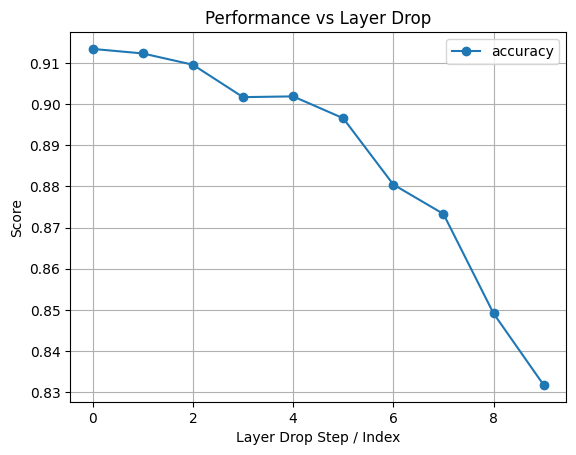

In [40]:
import matplotlib.pyplot as plt

performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()